# VOOT Business Analytics Case Study

## Objective
Wayne Inc. is a small US retailer with stores in New York and Los Angeles.

The goal is to improve **profit margins without reducing revenue**.

## Business Questions
1. Identify the **Top 5 customers who purchased in multiple stores** for a 10% discount campaign.
2. Evaluate the **revenue increase from the TV campaign** run from 1 Sep to 30 Sep 2012.
3. Identify **one store that can be closed** and evaluate the impact.
4. Evaluate the **impact of removing Product C**, assuming customers will buy Product A instead.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid", font_scale=1)
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Desktop\VOOT Business Analytics_Case Study\Customer Analysis_Raw Data.csv")
df.head()

,Customer_ID,Transaction_date,Order_ID,Revenue,Margin,Product_ID,Units,Store_ID
0,1101,15-05-2012,18758472,35,7.98,B,5,NY_222
1,1103,15-08-2012,14759294,38,7.92,B,5,NY_222
2,1104,11-12-2012,18277646,38,8.05,B,5,NY_222
3,1105,13-09-2012,18235117,38,7,B,6,NY_222
4,1105,06-09-2012,19783226,38,7.98,A,8,NY_333


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Customer_ID       197 non-null    int64 
 1   Transaction_date  197 non-null    object
 2   Order_ID          197 non-null    int64 
 3   Revenue           197 non-null    object
 4   Margin            197 non-null    object
 5   Product_ID        197 non-null    object
 6   Units             197 non-null    int64 
 7   Store_ID          197 non-null    object
dtypes: int64(3), object(5)
memory usage: 12.4+ KB


,Customer_ID,Order_ID,Units
count,197.000000,1.970000e+02,197.000000
mean,1249.822335,1.696301e+07,6.040609
std,91.360767,1.741608e+06,1.606230
min,1101.000000,1.376815e+07,3.000000
25%,1171.000000,1.554050e+07,5.000000
50%,1241.000000,1.705870e+07,6.000000
75%,1325.000000,1.845549e+07,7.000000
max,1398.000000,1.978323e+07,9.000000


In [4]:
print("Total rows:", len(df))
print("Unique customers:", df["Customer_ID"].nunique())
print("Unique stores:", df["Store_ID"].nunique())
print("Unique products:", df["Product_ID"].nunique())
print("Unique orders:", df["Order_ID"].nunique())

Total rows: 197
Unique customers: 146
Unique stores: 6
Unique products: 3
Unique orders: 197


In [5]:
df["Transaction_date"] = pd.to_datetime(df["Transaction_date"], format="%d-%m-%Y")

df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")
df["Margin"] = pd.to_numeric(df["Margin"], errors="coerce")

df.dtypes

Customer_ID                  int64
Transaction_date    datetime64[ns]
Order_ID                     int64
Revenue                    float64
Margin                     float64
Product_ID                  object
Units                        int64
Store_ID                    object
dtype: object

In [6]:
df.isnull().sum()

Customer_ID         0
Transaction_date    0
Order_ID            0
Revenue             2
Margin              2
Product_ID          0
Units               0
Store_ID            0
dtype: int64

### Handling Missing Values

The dataset contained 4 rows with missing values in Revenue or Margin.
Since these records represent a very small portion of the dataset,
they were removed to avoid inaccuracies in revenue and profitability analysis.

In [7]:
df[df["Revenue"].isnull() | df["Margin"].isnull()]

,Customer_ID,Transaction_date,Order_ID,Revenue,Margin,Product_ID,Units,Store_ID
8,1111,2013-01-02,18070703,NaN,8.05,B,4,LA_222
89,1223,2012-06-16,15032583,35.0,NaN,B,6,NY_222
157,1357,2012-09-16,15647394,NaN,7.00,A,6,NY_333
183,1383,2013-01-09,13974818,38.0,NaN,B,7,LA_111


In [8]:
df = df.dropna(subset=["Revenue", "Margin"])

In [9]:
df.isnull().sum()

Customer_ID         0
Transaction_date    0
Order_ID            0
Revenue             0
Margin              0
Product_ID          0
Units               0
Store_ID            0
dtype: int64

In [10]:
store_perf = df.groupby("Store_ID").agg(
    revenue=("Revenue","sum"),
    margin=("Margin","sum"),
    units=("Units","sum"),
    orders=("Order_ID","nunique")
).sort_values("revenue", ascending=False)

store_perf

,revenue,margin,units,orders
Store_ID,,,,
LA_111,1914.0,410.72,338,57
NY_111,1203.0,249.18,189,33
NY_222,1189.0,273.25,225,37
LA_222,823.0,185.71,160,25
NY_333,756.0,174.33,149,22
LA_333,655.0,145.72,106,19


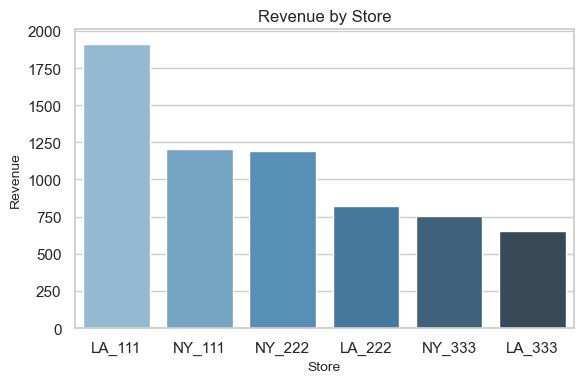

In [11]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=store_perf.index,
    y=store_perf["revenue"],
    hue=store_perf.index,
    palette="Blues_d",
    legend=False
)

plt.title("Revenue by Store", fontsize=12)
plt.xlabel("Store", fontsize=10)
plt.ylabel("Revenue", fontsize=10)

plt.tight_layout()
plt.show()

In [12]:
product_perf = df.groupby("Product_ID").agg(
    revenue=("Revenue","sum"),
    margin=("Margin","sum"),
    units=("Units","sum")
).sort_values("revenue", ascending=False)

product_perf

,revenue,margin,units
Product_ID,,,
B,2738.0,557.35,436
A,2197.0,602.48,568
C,1605.0,279.08,163


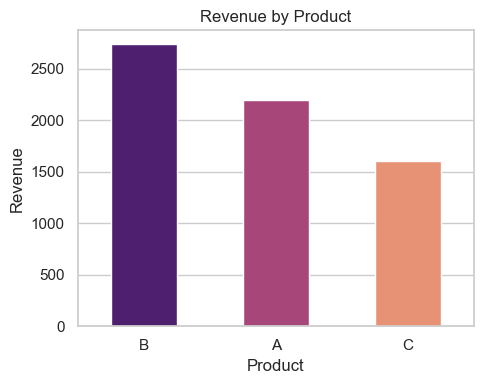

In [13]:
plt.figure(figsize=(5,4))

sns.barplot(
    x=product_perf.index,
    y=product_perf["revenue"],
    hue=product_perf.index,
    palette="magma",
    legend=False,
    width=0.5
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [14]:
customer_perf = df.groupby("Customer_ID").agg(
    revenue=("Revenue","sum"),
    orders=("Order_ID","nunique"),
    stores=("Store_ID","nunique")
).sort_values("revenue", ascending=False)

customer_perf.head()

,revenue,orders,stores
Customer_ID,,,
1124,192.0,5,3
1221,129.0,4,3
1219,113.0,3,3
1148,101.0,3,2
1270,92.0,3,1


### Question 1 — Top 5 Multi-Store Customers

In [15]:
multi_store_customers = customer_perf[customer_perf["stores"] > 1]

top5_customers = multi_store_customers.sort_values(
    "revenue", ascending=False
).head(5)

top5_customers

,revenue,orders,stores
Customer_ID,,,
1124,192.0,5,3
1221,129.0,4,3
1219,113.0,3,3
1148,101.0,3,2
1393,85.0,2,2


### Question 2 — TV Campaign Impact

In [16]:
df["month"] = df["Transaction_date"].dt.to_period("M")

In [17]:
monthly_revenue = df.groupby("month")["Revenue"].sum()
monthly_revenue

month
2012-01    199.0
2012-02    301.0
2012-03    528.0
2012-04    506.0
2012-05    696.0
2012-06    557.0
2012-07    309.0
2012-08    598.0
2012-09    691.0
2012-10    695.0
2012-11    491.0
2012-12    566.0
2013-01    403.0
Freq: M, Name: Revenue, dtype: float64

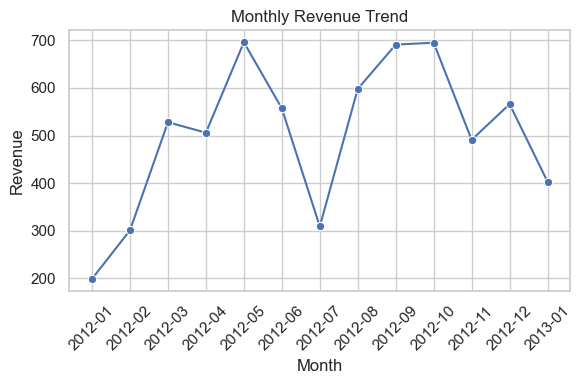

In [18]:
plt.figure(figsize=(6,4))

sns.lineplot(
    x=monthly_revenue.index.astype(str),
    y=monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
campaign_revenue = df[
    (df["Transaction_date"] >= "2012-09-01") &
    (df["Transaction_date"] <= "2012-09-30")
]["Revenue"].sum()

campaign_revenue

np.float64(691.0)

In [20]:
baseline_revenue = df[
    (df["Transaction_date"] >= "2012-08-01") &
    (df["Transaction_date"] <= "2012-08-31")
]["Revenue"].sum()

baseline_revenue

np.float64(598.0)

In [21]:
revenue_increase = campaign_revenue - baseline_revenue

print("Revenue increase due to campaign:", revenue_increase)

Revenue increase due to campaign: 93.0


In [22]:
lift = round((revenue_increase / baseline_revenue) * 100 ,2)
print("Revenue lift (%):", lift)

Revenue lift (%): 15.55


### Question 3 — Store Closure Impact

In [23]:
store_perf.sort_values("revenue")

,revenue,margin,units,orders
Store_ID,,,,
LA_333,655.0,145.72,106,19
NY_333,756.0,174.33,149,22
LA_222,823.0,185.71,160,25
NY_222,1189.0,273.25,225,37
NY_111,1203.0,249.18,189,33
LA_111,1914.0,410.72,338,57


In [24]:
la_customers = df[df["Store_ID"] == "LA_333"]["Customer_ID"].unique()

In [25]:
customer_store_count = (
    df[df["Customer_ID"].isin(la_customers)]
    .groupby("Customer_ID")["Store_ID"]
    .nunique()
)

In [26]:
single_store_customers = customer_store_count[customer_store_count == 1]
len(single_store_customers)

13

In [27]:
risk_revenue = df[df["Customer_ID"].isin(single_store_customers.index)]["Revenue"].sum()
risk_revenue

np.float64(432.0)

In [28]:
multi_store_customers = customer_store_count[customer_store_count > 1]
migration_revenue = df[df["Customer_ID"].isin(multi_store_customers.index)]["Revenue"].sum()
migration_revenue

np.float64(447.0)

### Question 4 — Product C Removal Impact

In [29]:
product_stats = df.groupby("Product_ID").agg(
    revenue=("Revenue","sum"),
    margin=("Margin","sum"),
    units=("Units","sum")
)

product_stats

,revenue,margin,units
Product_ID,,,
A,2197.0,602.48,568
B,2738.0,557.35,436
C,1605.0,279.08,163


In [30]:
rev_A, mar_A, unit_A = product_stats.loc["A"]
rev_C, mar_C, unit_C = product_stats.loc["C"]

In [31]:
price_A = rev_A / unit_A
margin_per_unit_A = mar_A / unit_A

In [32]:
new_units_A = unit_A + unit_C

new_revenue_A = price_A * new_units_A
new_margin_A = margin_per_unit_A * new_units_A

In [33]:
old_revenue = rev_A + rev_C
old_margin = mar_A + mar_C

revenue_change = new_revenue_A - old_revenue
margin_change = new_margin_A - old_margin

print("Revenue change:", round(revenue_change,2))
print("Margin change:", round(margin_change,2))

Revenue change: -974.52
Margin change: -106.19


## Key Findings

1. Top multi-store customers were identified for targeted promotions.
2. The TV campaign increased revenue during September 2012.
3. Store LA_333 is the weakest store and could be considered for closure.
4. Removing Product C reduces revenue and margin, so it should be retained.

## Strategic Recommendation
Wayne Inc. should focus on targeted marketing campaigns, evaluate closing LA_333 to reduce operational costs, and continue selling Product C due to its higher profitability.